In [115]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from scipy.stats import ttest_ind, mannwhitneyu
from matplotlib import cm
from scipy.ndimage import gaussian_filter


# This is custom Made .py files, we import them as tere are functions we need to unpack and prepare the data
from Parser import parse_samples, parse_events, convert_dict_to_df
from Renderer import drawing_traces
from video_traces import movie_traces

In [117]:
''' Data variables
* asc_samples_pd : only timesteps when recording
    notes: there are gaps in data - it is when eye tracker were paused (no recordings)
    pd.DataFrame:
        columns: time, x, y, pupil 
'''

'''
asc_samples_pd: 
    columns: time, x, y, pupil
trials_data:
    columns: path_name_trial, start_trial, end_trial, num_fix, num_sacc, num_blinks 
'''

'\nasc_samples_pd: \n    columns: time, x, y, pupil\ntrials_data:\n    columns: path_name_trial, start_trial, end_trial, num_fix, num_sacc, num_blinks \n'

In [118]:
# 0. Defining file paths

current_path = os.getcwd()

respondents = ['resp_0'] #TODO here we will read a txt file that contain ALL info about all resp folder names
# in that case only 'resp_0'
current_respondent = respondents[0] #TODO loop or whatever

respondent_folder = os.path.join(current_path, current_respondent)
data_folder_name = current_respondent + '/Data'
stimuli_folder_name = current_respondent + '/Stimuli'

samples_only_folder = 'asc_samples_only'
events_only_folder = 'asc_events_only'
events_samples_folder = 'asc_events_samples'
data_path = os.path.join(current_path, data_folder_name)

# important paths
data_samples_path = os.path.join(data_path, samples_only_folder)
data_events_path = os.path.join(data_path, events_only_folder)
data_events_samples_path = os.path.join(data_path, events_samples_folder)
stimuli_path = os.path.join(current_path, stimuli_folder_name)


filenames = [f for f in os.listdir(os.path.join(data_path, 'edf')) if f.endswith('.edf')]

In [119]:
# STATE HERE ........training
# Here are the names of teh file
# file_name = 'alyatrainingtrack.asc' #TODO: loop or whatever
# experiment_name = 'alyatrainingtrack'
# stimuli_name = 'training/images'
# STATE HERE ........

experiments = ['A', 'B', 'C', 'D']
durations = {}
fixations = {}
trials_data_dict = {}
asc_samples_dict  = {}
csv_dict = {}
fixations_pd_in_dict = {}
stimuli_img_path_dict =  {}
write_traces_folder_dict = {}
write_video_folder_dict ={}
saccades_dict ={}


In [120]:
for i, exp in enumerate(experiments):
    if exp == 'A':
        # STATE HERE ........12_A
        file_name = 'alya12_atrack.asc' #TODO: loop or whatever
        experiment_name = 'alya12_atrack'
        stimuli_name = 'stimuli_exp_12_a'
        # STATE HERE ........
    elif exp == 'B':
        # STATE HERE ........12_B
        file_name = 'alya12_btrack.asc' #TODO: loop or whatever
        experiment_name = 'alya12_btrack'
        stimuli_name = 'stimuli_exp_12_b'
        # STATE HERE ........
    elif exp == 'C':
        # STATE HERE ........12_C
        file_name = 'alya12_ctrack.asc' #TODO: loop or whatever
        experiment_name = 'alya12_ctrack'
        stimuli_name = 'stimuli_exp_12_c'
        # STATE HERE ........
    elif exp == 'D':
        # STATE HERE ........12_D
        file_name = 'alya12_dtrack.asc' #TODO: loop or whatever
        experiment_name = 'alya12_dtrack'
        stimuli_name = 'stimuli_exp_12_d'
        # STATE HERE ........


    print('EXPERIMENT:')
    print(experiment_name)
    print('--------------------------')

    # STimuli for experiment
    stimuli_img_path = os.path.join(stimuli_path, stimuli_name, 'images')
    stimuli_img_path_dict[exp] = stimuli_img_path

    # Traces images paths 
    traces_folder = os.path.join(data_path, 'traces')
    os.makedirs(traces_folder) if not os.path.exists(traces_folder) else None
    write_traces_folder = os.path.join(traces_folder, experiment_name)
    os.makedirs(write_traces_folder) if not os.path.exists(write_traces_folder) else None

    write_traces_folder_dict[exp] = write_traces_folder
    # saccades_dict[exp] = sacc_data # IMOSE added


    # Video gaze path
    video_path = os.path.join(data_path, 'video')
    os.makedirs(video_path) if not os.path.exists(video_path) else None
    write_video_folder = os.path.join(video_path, experiment_name)
    os.makedirs(write_video_folder) if not os.path.exists(write_video_folder) else None

    write_video_folder_dict[exp] = write_video_folder

    # 1. Parsing samples
    event_samples = os.path.join(data_events_samples_path, file_name)
    events_path = os.path.join(data_events_path, file_name)
    samples_path = os.path.join(data_samples_path, file_name)
    asc_samples_pd = parse_samples(samples_path)


    # 2. Parsing events
    meta, events = parse_events(events_path)
    trials_data, fix_data, sacc_data, blink_data = convert_dict_to_df(events)
    trials_data['duration_sec'] = (trials_data['end_trial'] - trials_data['start_trial']) / 1000
    saccades_dict[exp] = sacc_data #Alina: [in my, when this line at previous position it gives error, so I put it here]

    # 3. Reading info about trials
    csv_folder_name = stimuli_name + '/csv'
    file_name = 'experiment.csv'
    csv_path = os.path.join(stimuli_path, csv_folder_name, file_name)
    csv_iminfo = pd.read_csv(csv_path, sep=';', encoding='utf-8')
    last_trial_number = csv_iminfo['N_trial'].max() + 1
    new_name = f'c:\\Users\\Alina\\Downloads\\Mental_Rotation_and_Lab\\pop_out_effect_code\\experiment_results\\exp_0\\images\\image_{int(last_trial_number)}.png'
    # 3. Define the condition
    condition = (
        (csv_iminfo['N_trial'] == 0) &
        (csv_iminfo['name'] == r'c:\Users\Alina\Downloads\Mental_Rotation_and_Lab\pop_out_effect_code\experiment_results\exp_0\images\image_0.png')
    )
    csv_iminfo.loc[condition, 'N_trial'] = last_trial_number
    csv_iminfo.loc[condition, 'name'] = new_name

    # Data analysis

    trials_data['trial_id'] = trials_data['trial_id'].astype(int)

    trial_data_merged = pd.merge(trials_data, csv_iminfo[['N_trial', 'target_presence']],
                        left_on='trial_id', right_on='N_trial',
                        how='left')  # or 'inner' if you're sure all match
    trial_data_merged.drop(columns='N_trial', inplace=True)


    fix_data['trial_id_num'] = fix_data['trial_id'].astype(int)
    fixation_data_merged = pd.merge(fix_data, csv_iminfo[['N_trial', 'target_presence']],
                        left_on='trial_id_num', right_on='N_trial',
                        how='left')  # or 'inner' if you're sure all match
    fixation_data_merged.drop(columns='N_trial', inplace=True)

    # 1. All data description
    data_desc = trial_data_merged[['duration_sec', 'num_sacc', 'num_blinks', 'num_fix']].describe()
    # print('ALL_DATA:', '\n')
    # print(data_desc, '\n')

    # 2. Target only description
    trials_data_target = trial_data_merged[trial_data_merged['target_presence']==True]
    target_desc = trials_data_target[['duration_sec', 'num_sacc', 'num_blinks', 'num_fix']].describe()
    # print('TARGET_ONLY:', '\n')
    # print(target_desc, '\n') 

    # 3. NO Target description
    trials_data_NO_target = trial_data_merged[trial_data_merged['target_presence']==False]
    NO_target_desc = trials_data_NO_target[['duration_sec', 'num_sacc', 'num_blinks', 'num_fix']].describe()
    # print('NO_TARGET:', '\n')
    # print(NO_target_desc, '\n')


    # Preparing data for all experiments together 
    durations[exp] = np.array(trials_data_target['duration_sec'])
    fixations[exp] = {}
    trials_data_dict[exp] = trial_data_merged
    asc_samples_dict[exp] = asc_samples_pd
    csv_dict[exp] = csv_iminfo
    fixations_pd_in_dict[exp] = fixation_data_merged

    # Group by trial_id
    for trial_id, group in fix_data.groupby('trial_id'):
        fixations[exp][str(trial_id)] = {
            'x': group['avrxpos'].to_numpy(),
            'y': group['avrypos'].to_numpy(),
            'duration': group['duration'].to_numpy()
        }

EXPERIMENT:
alya12_atrack
--------------------------
EXPERIMENT:
alya12_btrack
--------------------------
EXPERIMENT:
alya12_ctrack
--------------------------
EXPERIMENT:
alya12_dtrack
--------------------------


In [122]:
#fixations_pd_in_dict['A']

# Calibration 

In [125]:
width = 1920
height = 1080

for experiment in experiments:
    # Set up an empty heatmap
    heatmap = np.zeros((height, width)) # height - rows, width - columns
    # Loop over trials 1 to 60
    for trial_num in range(1, 61):
        trial = str(trial_num)  # make sure keys are strings
        if trial in fixations[experiment]:  # check if trial exists
            x = fixations[experiment][trial]['x']
            y = fixations[experiment][trial]['y']
            fix_duration = fixations[experiment][trial]['duration']

            for xi, yi, di in zip(x, y, fix_duration):
                if 0 <= xi < width and 0 <= yi < height:
                    heatmap[int(yi), int(xi)] += di

    # Save original max for rescaling
    original_max = heatmap.max()

    # Apply Gaussian smoothing
    heatmap_smooth = gaussian_filter(heatmap, sigma=25)

    # Rescale to preserve original max
    heatmap_smooth *= original_max / heatmap_smooth.max()

    # Download coordinates 
    with open('grid_coords.txt', 'r') as f:
        grid_coords_txt = [tuple(map(int, line.strip().split(','))) for line in f]

    x_grid_coord, y_grid_coord = zip(*grid_coords_txt)


    max_y, max_x = np.unravel_index(np.argmax(heatmap_smooth), heatmap_smooth.shape)
    if experiment != 'C':
        center_x, center_y = x_grid_coord[12], y_grid_coord[12] #center of the grid 
    else:
        center_x, center_y = x_grid_coord[16], y_grid_coord[16] #center of the grid 
    # Plot
    # plt.figure(figsize=(12, 7))
    # img = plt.imshow(heatmap_smooth, cmap='hot', interpolation='bilinear')
    # plt.scatter(x_grid_coord, y_grid_coord, c='white', marker='x', s=50, linewidths=1)
    # plt.colorbar(img, label='Fixation Duration (ms)')
    # plt.title("Summed Gaze Duration Heatmap: "+ experiment)
    # #plt.colorbar(img, label='Fixation Duration (ms)')
    # plt.axis('off')
    # # plt.show()


    # SHIFTED SCATTER
    dy = center_y - max_y
    dx = center_x - max_x

    fixations_pd_in_dict[experiment]['shifted_avrxpos'] = fixations_pd_in_dict[experiment]['avrxpos'] + dx
    fixations_pd_in_dict[experiment]['shifted_avrypos'] = fixations_pd_in_dict[experiment]['avrypos'] + dy
    
    # Shift the smoothed heatmap
    from scipy.ndimage import shift
    heatmap_shifted = shift(heatmap_smooth, shift=(dy, dx), mode='constant', cval=0)

    plt.figure(figsize=(12, 7))
    # img = plt.imshow(heatmap_shifted, cmap='hot', interpolation='bilinear')
    # plt.scatter(x_grid_coord, y_grid_coord, c='white', marker='x', s=50, linewidths=1)
    # plt.colorbar(img, label='Fixation Duration (ms)')
    # plt.title("Shifted Summed Gaze Duration Heatmap: "+ experiment)
    # #plt.colorbar(img, label='Fixation Duration (ms)')
    # plt.axis('off')
    # # plt.show()


    # DRAWING shifted traces
    for i in range(1, 61):
        trial_id = str(i)
        # trials_data_dict[experiment] = trials_trials_data_dict[experiment]_dict[experiment]
        trial_info = trials_data_dict[experiment].loc[trials_data_dict[experiment]['trial_id'] == int(trial_id)]

        stime = trial_info['start_trial'].iloc[0]
        etime = trial_info['end_trial'].iloc[0]
        asc = asc_samples_dict[experiment]
        timestemps = asc.loc[(asc['time'] >= stime) & (asc['time'] <= etime)].copy().assign(x=lambda df: df['x'] + dx,
                          y=lambda df: df['y'] + dy)

        
        csv_data = csv_dict[experiment]
        target_area = csv_data.loc[csv_data['N_trial'] == int(trial_id)]
        
        fix = fixations_pd_in_dict[experiment].loc[fixations_pd_in_dict[experiment]['trial_id'] == str(trial_id)].copy().assign(
            avrxpos=lambda df: df['avrxpos'] + dx, 
            avrypos=lambda df: df['avrypos'] + dy
)
        


        traces = drawing_traces(stimuli_img_path_dict[experiment], write_traces_folder_dict[experiment], stimuli_path, 
                                trial_id, timestemps, 
                                fix, target_area)
        
        
        #  *UNCOMMENT* Video traces movie
        # img_path = os.path.join(write_traces_folder_dict[experiment], f'traces_trial_{i}.png')
        # movie_traces(img_path, timestemps, i, write_video_folder_dict[experiment])

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

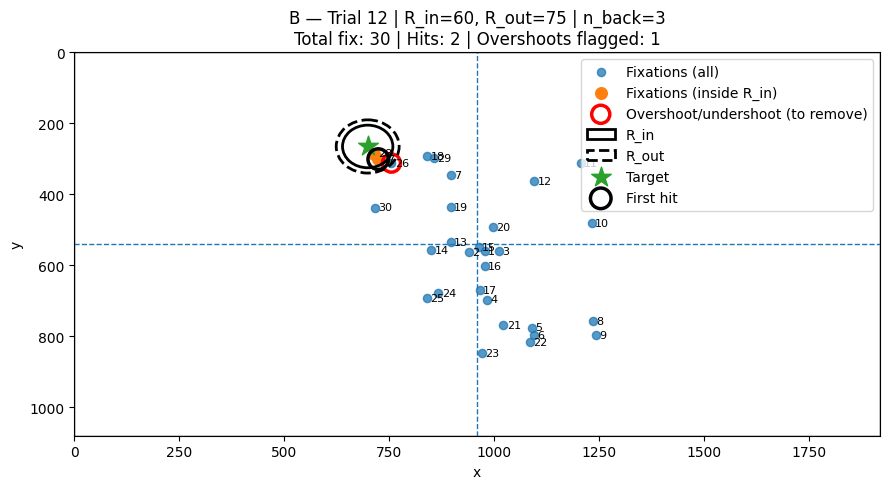

In [94]:
#Filtering corrective saccades

R_def = 75

grid_xy = np.array(grid_coords_txt)
xs = np.unique(grid_xy[:,0])
ys = np.unique(grid_xy[:,1])
dx = np.min(np.diff(np.sort(xs)))
dy = np.min(np.diff(np.sort(ys)))
spacing = min(dx, dy)
half_spacing = spacing / 2
R_out = half_spacing - 1    #TESTI values
R_in  = min(60, R_out)      #TESTING

def remove_pre_hit_overshoot_fixations(
    fix_df: pd.DataFrame,
    target_df: pd.DataFrame,
    R_in: float,
    R_out: float,
    n_back: int = 3,              
    time_window_ms: int | None = None,  
    trial_col_fix: str = "trial_id",
    trial_col_tgt: str = "N_trial",
    x_col: str = "shifted_avrxpos",
    y_col: str = "shifted_avrypos",
    t_col: str = "stime",
    tx_col: str = "txpos",
    ty_col: str = "typos",
):
    f = fix_df.copy()
    f[trial_col_fix] = pd.to_numeric(f[trial_col_fix], errors="coerce").astype("Int64")

    t = target_df[[trial_col_tgt, tx_col, ty_col]].copy()
    t[trial_col_tgt] = pd.to_numeric(t[trial_col_tgt], errors="coerce").astype("Int64")

    m = f.merge(t, left_on=trial_col_fix, right_on=trial_col_tgt, how="inner")

    # extra to clean
    m = m.dropna(subset=[x_col, y_col, t_col, tx_col, ty_col]).copy()
    m[t_col] = pd.to_numeric(m[t_col], errors="coerce")
    m = m.dropna(subset=[t_col]).copy()

    #distance to target
    dx = m[x_col].astype(float) - m[tx_col].astype(float)
    dy = m[y_col].astype(float) - m[ty_col].astype(float)
    m["dist_to_target"] = np.sqrt(dx*dx + dy*dy)

#flagging
    m["is_hit"] = m["dist_to_target"] <= R_in
    m["is_ring_miss"] = (m["dist_to_target"] > R_in) & (m["dist_to_target"] <= R_out)

    #mark rows to drop
    m["drop_overshoot"] = False

    # process per trial in time order
    for trial_id, g in m.groupby(trial_col_fix, sort=False):
        g_sorted = g.sort_values(t_col)
        hit_idxs = g_sorted.index[g_sorted["is_hit"]].to_list()
        if not hit_idxs:
            continue

        first_hit_idx = hit_idxs[0]
        first_hit_time = float(g_sorted.loc[first_hit_idx, t_col])

        # candidates before first hit
        before = g_sorted.loc[g_sorted[t_col] < first_hit_time]

        if time_window_ms is not None:
            before = before.loc[before[t_col] >= (first_hit_time - time_window_ms)]

        # take last n_back fixations before hit
        if n_back is not None and n_back > 0:
            before = before.tail(n_back)

        # drop only those in the ring (near-target misses)
        drop_idxs = before.index[before["is_ring_miss"]].to_list()
        m.loc[drop_idxs, "drop_overshoot"] = True

    # return "cleaned" fixations (keeping everything except the overshoot ring misses)
    cleaned = m.loc[~m["drop_overshoot"]].copy()
    return cleaned, m  

clean_fixations_pd_in_dict = {}
annotated_fixations_pd_in_dict = {}

for exp_key, fix_df in fixations_pd_in_dict.items():
    tgt_df = target_coords[exp_key]

    cleaned, annotated = remove_pre_hit_overshoot_fixations(
        fix_df=fix_df,
        target_df=tgt_df,
        R_in=60,
        R_out=R_def,
        n_back=3,             
        time_window_ms=None,   
        trial_col_fix="trial_id_num",   
        trial_col_tgt="N_trial",
        x_col="shifted_avrxpos",
        y_col="shifted_avrypos",
        t_col="stime",
        tx_col="txpos",
        ty_col="typos",
    )


    clean_fixations_pd_in_dict[exp_key] = cleaned
    annotated_fixations_pd_in_dict[exp_key] = annotated

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_trial_fixations_with_overshoots(
    exp_key,
    trial_id,
    fixations_pd_in_dict,
    target_coords,
    R_in=60,
    R_out=R_def,
    n_back=3,                
    time_window_ms=None,     
    W=1920, H=1080,
    trial_col_fix="trial_id_num",  
    trial_col_tgt="N_trial",
    x_col="shifted_avrxpos",
    y_col="shifted_avrypos",
    t_col="stime",
    show_order=True
):

#THIS TRIAL

    tdf = target_coords[exp_key].copy()
    trow = tdf.loc[tdf[trial_col_tgt] == trial_id]
    if trow.empty:
        raise ValueError(f"Trial {trial_id} not found in target_coords[{exp_key}]")
    tx = float(trow.iloc[0]["txpos"])
    ty = float(trow.iloc[0]["typos"])

    #fixations 
    fdf = fixations_pd_in_dict[exp_key].copy()
    fdf[trial_col_fix] = pd.to_numeric(fdf[trial_col_fix], errors="coerce").astype("Int64")
    fdf[t_col] = pd.to_numeric(fdf[t_col], errors="coerce")

    ftrial = fdf.loc[fdf[trial_col_fix] == trial_id, [t_col, x_col, y_col]].dropna()
    if ftrial.empty:
        print(f"No fixations for {exp_key} trial {trial_id}")
        return

    ftrial = ftrial.sort_values(t_col).reset_index(drop=True)

    xs = ftrial[x_col].astype(float).to_numpy()
    ys = ftrial[y_col].astype(float).to_numpy()
    ts = ftrial[t_col].astype(float).to_numpy()

    #distances to target
    d = np.sqrt((xs - tx)**2 + (ys - ty)**2)
    is_hit = d <= R_in

    # find first hit
    if not is_hit.any():
        first_hit_i = None
        overshoot_mask = np.zeros_like(is_hit, dtype=bool)
    else:
        first_hit_i = int(np.argmax(is_hit))  # first True in time order
        t_hit = ts[first_hit_i]

        # candidates before hit
        cand_idx = np.arange(0, first_hit_i)

        if time_window_ms is not None:
            cand_idx = cand_idx[ts[cand_idx] >= (t_hit - time_window_ms)]

        # last n_back fixations before hit
        if n_back is not None and n_back > 0 and cand_idx.size > 0:
            cand_idx = cand_idx[-n_back:]

        # overshoot/undershoot = in ring right before hit
        overshoot_mask = np.zeros_like(is_hit, dtype=bool)
        ring = (d > R_in) & (d <= R_out)
        overshoot_mask[cand_idx] = ring[cand_idx]

    #PLOTTING
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.add_patch(plt.Rectangle((0, 0), W, H, fill=False, linewidth=1))
    ax.axvline(W/2, linestyle="--", linewidth=1)
    ax.axhline(H/2, linestyle="--", linewidth=1)

    # all fixations
    ax.scatter(xs, ys, s=35, alpha=0.75, label="Fixations (all)")

    # hits inside R_in
    ax.scatter(xs[is_hit], ys[is_hit], s=70, label="Fixations (inside R_in)")

    # overshoots to remove (ring misses right before hit)
    ax.scatter(xs[overshoot_mask], ys[overshoot_mask],
               s=170, facecolors="none", edgecolors="red", linewidths=2.5,
               label="Overshoot/undershoot (to remove)")

    # draw circles + target
    ax.add_patch(Circle((tx, ty), R_in, fill=False, linewidth=2, label="R_in"))
    ax.add_patch(Circle((tx, ty), R_out, fill=False, linestyle="--", linewidth=2, label="R_out"))
    ax.scatter([tx], [ty], s=220, marker="*", label="Target")

    # mark first hit
    if first_hit_i is not None:
        ax.scatter([xs[first_hit_i]], [ys[first_hit_i]], s=220, facecolors="none",
                   edgecolors="black", linewidths=2.5, label="First hit")

    # annotate order
    if show_order:
        for i, (x, y) in enumerate(zip(xs, ys), start=1):
            ax.text(x + 8, y + 8, str(i), fontsize=8)

    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.set_title(
        f"{exp_key} — Trial {trial_id} | R_in={R_in}, R_out={R_out} | n_back={n_back}\n"
        f"Total fix: {len(xs)} | Hits: {int(is_hit.sum())} | Overshoots flagged: {int(overshoot_mask.sum())}"
    )
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

plot_trial_fixations_with_overshoots(
    exp_key="B",
    trial_id=12,
    fixations_pd_in_dict=fixations_pd_in_dict,
    target_coords=target_coords,
    R_in=60,
    R_out=R_def,
    n_back=3,
    time_window_ms=None
)



In [89]:
#how many fixations got removed 
a = annotated_fixations_pd_in_dict["C"]
print("Removed:", int(a["drop_overshoot"].sum()))

Removed: 2


In [90]:
import pandas as pd

rows = []
for exp_key, ann in annotated_fixations_pd_in_dict.items():
    tmp = (
        ann.groupby("trial_id_num")["drop_overshoot"]
        .sum()
        .reset_index(name="n_overshoots")
    )
    tmp["exp_key"] = exp_key
    rows.append(tmp)

overshoot_trials = (
    pd.concat(rows, ignore_index=True)
      .query("n_overshoots > 0")
      .sort_values(["exp_key", "trial_id_num"])
      .reset_index(drop=True)
)
overshoot_trials

,trial_id_num,n_overshoots,exp_key
0,5,1,A
1,9,1,A
2,30,1,A
3,32,1,A
4,36,1,A
5,43,1,A
6,46,1,A
7,48,1,A
8,53,1,A
9,55,1,A


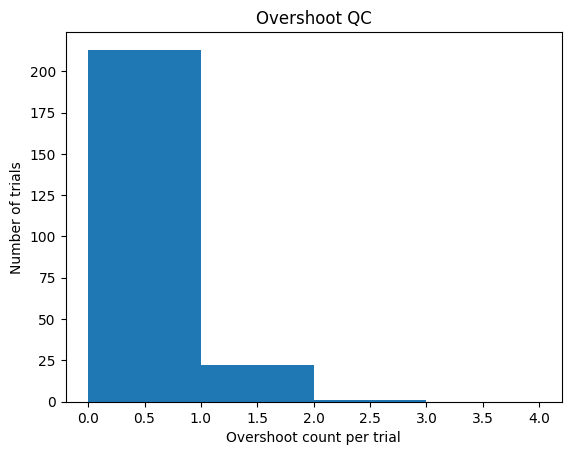

In [129]:
R_in = 60
R_out = R_def
n_back = 3
overshoot_counts = []

for exp_key, df in fixations_pd_in_dict.items():

    tgt_df = target_coords[exp_key]

    for trial in df["trial_id_num"].dropna().unique():
        trow = tgt_df.loc[tgt_df["N_trial"] == trial]
        if trow.empty:
            continue
        tx = float(trow.iloc[0]["txpos"])
        ty = float(trow.iloc[0]["typos"])
        ftrial = df.loc[df["trial_id_num"] == trial].copy()
        ftrial = ftrial.sort_values("stime")
        xs = ftrial["shifted_avrxpos"].to_numpy()
        ys = ftrial["shifted_avrypos"].to_numpy()

        if len(xs) == 0:
            overshoot_counts.append(0)
            continue

        d = np.sqrt((xs - tx)**2 + (ys - ty)**2)
        is_hit = d <= R_in
        if not is_hit.any():
            overshoot_counts.append(0)
            continue

        first_hit_i = np.argmax(is_hit)
        cand_idx = np.arange(0, first_hit_i)

        if len(cand_idx) > 0:
            cand_idx = cand_idx[-n_back:]

        ring = (d > R_in) & (d <= R_out)
        overshoot_count = np.sum(ring[cand_idx])
        overshoot_counts.append(overshoot_count)


plt.hist(overshoot_counts, bins=range(5))
plt.xlabel("Overshoot count per trial")
plt.ylabel("Number of trials")
plt.title("Overshoot QC")
plt.show()

*** NEW ASSIGNMENT 9.3.

In [100]:
fix_data = clean_fixations_pd_in_dict['A'].copy()

fix_data['prev_x'] = fix_data.groupby('trial_id_num')['shifted_avrxpos'].shift(1)
fix_data['prev_y'] = fix_data.groupby('trial_id_num')['shifted_avrypos'].shift(1)

fix_data['euc_dist'] = np.sqrt(
    (fix_data['shifted_avrxpos'] - fix_data['prev_x'])**2 +
    (fix_data['shifted_avrypos'] - fix_data['prev_y'])**2
)

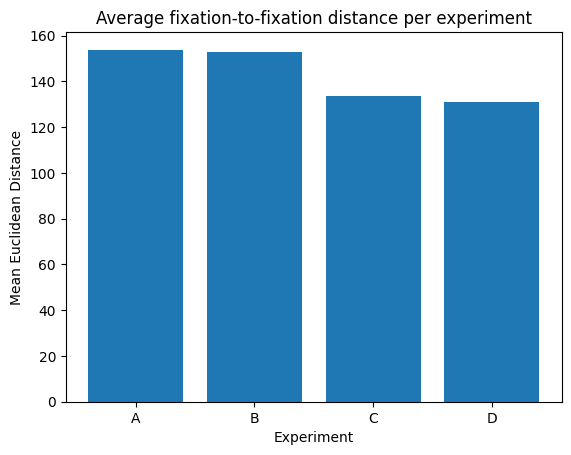

In [130]:
euc_means = {}
distances = {}

for exp_key, df in clean_fixations_pd_in_dict.items():

    d = df.copy()

    d['prev_x'] = d.groupby('trial_id_num')['shifted_avrxpos'].shift(1)
    d['prev_y'] = d.groupby('trial_id_num')['shifted_avrypos'].shift(1)
    d['euc_dist'] = np.sqrt((d['shifted_avrxpos'] - d['prev_x'])**2 + (d['shifted_avrypos'] - d['prev_y'])**2)
    euc_means[exp_key] = d['euc_dist'].mean()
    distances[exp_key] = d['euc_dist'].dropna()

#PLOT!
labels = list(euc_means.keys())
values = list(euc_means.values())
plt.bar(labels, values)
plt.xlabel("Experiment")
plt.ylabel("Mean Euclidean Distance")
plt.title("Average fixation-to-fixation distance per experiment")
plt.show()


A vs B: t=0.179, p=0.8581
A vs C: t=3.675, p=0.0002
A vs D: t=4.415, p=0.0000
B vs C: t=5.381, p=0.0000
B vs D: t=6.558, p=0.0000
C vs D: t=1.023, p=0.3065


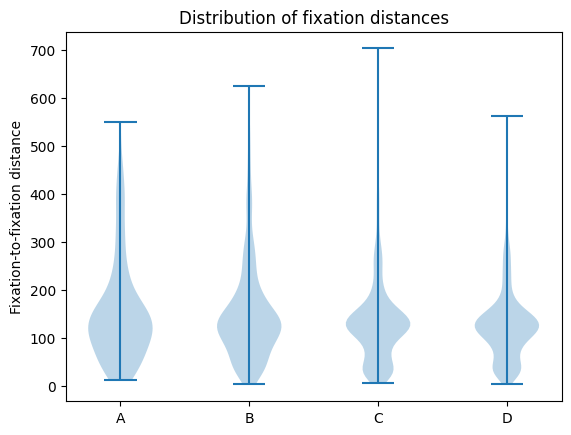

In [134]:
experiments = ['A','B','C','D']
means = {}
for i in range(len(experiments)):
    for j in range(i+1,len(experiments)):
        e = experiments[i]
        ee = experiments[j]

        stat,p = ttest_ind(distances[e], distances[ee])

        print(f"{e} vs {ee}: t={stat:.3f}, p={p:.4f}")

plt.violinplot(
    [distances['A'], distances['B'], distances['C'], distances['D']])

plt.xticks([1,2,3,4], ['A','B','C','D'])
plt.ylabel("Fixation-to-fixation distance")
plt.title("Distribution of fixation distances")
plt.show()

A: t=-3.237, p=0.0020
B: t=-2.709, p=0.0089
C: t=-1.378, p=0.1736
D: t=-1.000, p=0.3215


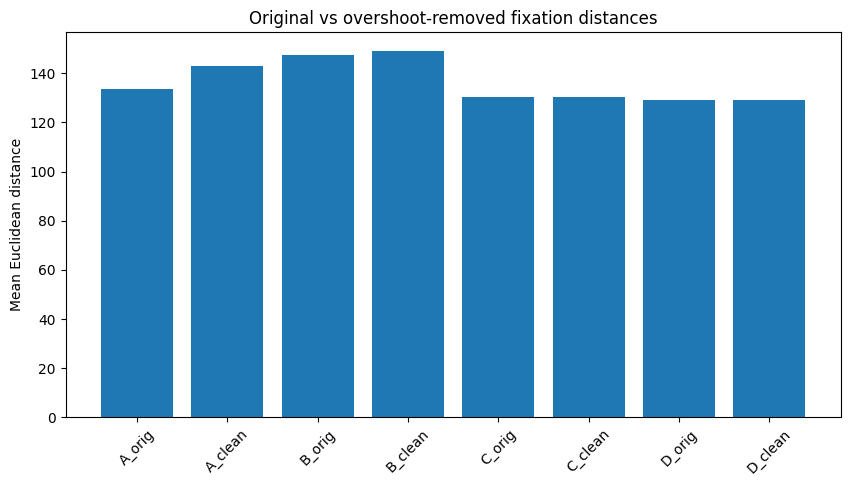

In [127]:
from scipy.stats import ttest_rel
labels = []
values = []

def compute_trial_mean_euc_dist(df, x_col, y_col, trial_col='trial_id_num'):
    d = df.copy()
    d['prev_x'] = d.groupby(trial_col)[x_col].shift(1)
    d['prev_y'] = d.groupby(trial_col)[y_col].shift(1)
    d['euc_dist'] = np.sqrt((d[x_col] - d['prev_x'])**2 + (d[y_col] - d['prev_y'])**2)
    return d.groupby(trial_col)['euc_dist'].mean()

trial_mean_orig = {}
trial_mean_clean = {}
for exp in ['A', 'B', 'C', 'D']:
    trial_mean_orig[exp] = compute_trial_mean_euc_dist(
        fixations_pd_in_dict[exp],
        x_col='avrxpos',
        y_col='avrypos',
        trial_col='trial_id_num')

    trial_mean_clean[exp] = compute_trial_mean_euc_dist(
        clean_fixations_pd_in_dict[exp],
        x_col='shifted_avrxpos',
        y_col='shifted_avrypos',
        trial_col='trial_id_num')

#TTEST
for exp in ['A', 'B', 'C', 'D']:
    paired = trial_mean_orig[exp].to_frame('orig').join(
        trial_mean_clean[exp].to_frame('clean'),
        how='inner').dropna()
    t, p = ttest_rel(paired['orig'], paired['clean'])
    print(f"{exp}: t={t:.3f}, p={p:.4f}")

#PLOT!
for exp in ['A', 'B', 'C', 'D']:
    labels.append(f"{exp}_orig")
    values.append(trial_mean_orig[exp].mean())
    labels.append(f"{exp}_clean")
    values.append(trial_mean_clean[exp].mean())

plt.figure(figsize=(10, 5))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.ylabel("Mean Euclidean distance")
plt.title("Original vs overshoot-removed fixation distances")
plt.show()


In [112]:
for exp in fixations_pd_in_dict:
    print("\nEXPERIMENT:", exp)
    print(fixations_pd_in_dict[exp].columns.tolist())


EXPERIMENT: A
['trial_id', 'path_name_trial', 'eye', 'stime', 'etime', 'duration', 'avrxpos', 'avrypos', 'avrpupilsize', 'trial_id_num', 'target_presence']

EXPERIMENT: B
['trial_id', 'path_name_trial', 'eye', 'stime', 'etime', 'duration', 'avrxpos', 'avrypos', 'avrpupilsize', 'trial_id_num', 'target_presence']

EXPERIMENT: C
['trial_id', 'path_name_trial', 'eye', 'stime', 'etime', 'duration', 'avrxpos', 'avrypos', 'avrpupilsize', 'trial_id_num', 'target_presence']

EXPERIMENT: D
['trial_id', 'path_name_trial', 'eye', 'stime', 'etime', 'duration', 'avrxpos', 'avrypos', 'avrpupilsize', 'trial_id_num', 'target_presence']


# Average Saccades distance: target_presence = True

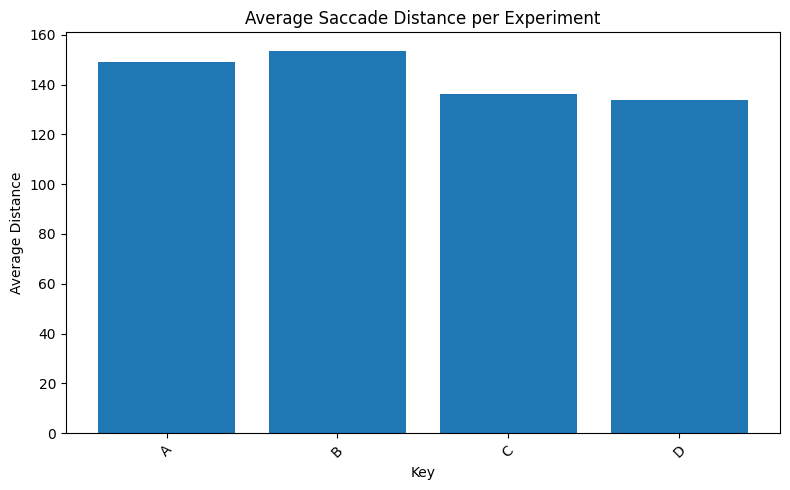

In [7]:

trials_data_dict['A'] #trial_id - we have column target_presence, only select those, when target is present target_presence==True
saccades_dict['A'] #trial_id
# select only those rows that saccades_dict['A'] 

# 1. Get the trials where target is present
present_trials = trials_data_dict['A'].loc[
    trials_data_dict['A']['target_presence'] == True, 'trial_id'
]

# 2. Filter saccades from those trials
saccades_with_target = saccades_dict['A'].loc[
    saccades_dict['A']['trial_id'].isin(present_trials)
]

for k in sorted(experiments):
    trials = trials_data_dict[k]
    sacc   = saccades_dict[k]

    for col in ['sxpos', 'sypos', 'expos', 'eypos']:
        sacc[col] = pd.to_numeric(sacc[col], errors='coerce')

    sacc['distance'] = np.sqrt((sacc['expos'] - sacc['sxpos'])**2 +
                               (sacc['eypos'] - sacc['sypos'])**2)
    

avg_distances = {}

for key, df in saccades_dict.items():
    avg_distances[key] = df['distance'].mean()

avg_df = pd.DataFrame(list(avg_distances.items()), columns=['Key', 'AverageDistance'])


plt.figure(figsize=(8, 5))
plt.bar(avg_df['Key'], avg_df['AverageDistance'])
plt.title('Average Saccade Distance per Experiment')
plt.xlabel('Key')
plt.ylabel('Average Distance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()






## T-test: significance of saccadic distances

In [9]:
from scipy.stats import ttest_ind

a = saccades_dict['A']['distance'].dropna()
b = saccades_dict['B']['distance'].dropna()
c = saccades_dict['C']['distance'].dropna()
d = saccades_dict['D']['distance'].dropna()

# two-tailed, independent t-tests
t_ab, p_ab = ttest_ind(a, b, equal_var=False)
t_bc, p_bc = ttest_ind(b, c, equal_var=False)
t_cd, p_cd = ttest_ind(c, d, equal_var=False)

print("T-test results, unequal variance):")
print(f"A vs B: t = {t_ab:.3f}, p = {p_ab:.6f}")
print(f"B vs C: t = {t_bc:.3f}, p = {p_bc:.6f}")
print(f"C vs D: t = {t_cd:.3f}, p = {p_cd:.6f}")

ttest_results = pd.DataFrame({
    'Comparison': ['A vs B', 'B vs C', 'C vs D'],
    't_value': [t_ab, t_bc, t_cd],
    'p_value': [p_ab, p_bc, p_cd]
})
print(ttest_results)

T-test results, unequal variance):
A vs B: t = -0.656, p = 0.512241
B vs C: t = 4.646, p = 0.000004
C vs D: t = 0.989, p = 0.322758
  Comparison   t_value   p_value
0     A vs B -0.655812  0.512241
1     B vs C  4.646403  0.000004
2     C vs D  0.988920  0.322758


In [10]:
#OLD PLOT

for key, df in saccades_dict.items():
    for col in ['sxpos', 'sypos', 'expos', 'eypos']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['distance'] = np.sqrt((df['expos'] - df['sxpos'])**2 + (df['eypos'] - df['sypos'])**2)

for key, df in saccades_dict.items():
    df['distance'] = np.sqrt((df['expos'] - df['sxpos'])**2 + (df['eypos'] - df['sypos'])**2)


#print(saccades_dict['A'])

#PLOT

avg_distances = {}

for key, df in saccades_dict.items():
    avg_distances[key] = df['distance'].mean()

avg_df = pd.DataFrame(list(avg_distances.items()), columns=['Key', 'AverageDistance'])

#plt.figure(figsize=(8, 5))
#plt.bar(avg_df['Key'], avg_df['AverageDistance'])
#plt.title('Average Distance per Key')
#plt.xlabel('Key')
#plt.ylabel('Average Distance')
#plt.xticks(rotation=45)
#plt.tight_layout()
#plt.show()

In [11]:
present_trials = []

for key, df in trials_data_dict.items():
    trials = df.loc[df['target_presence'] == True].copy()
    trials['experiment'] = key
    present_trials.append(trials)

present_trials = pd.concat(present_trials, ignore_index=True)
#present_trials.head(60)     

target_coords = []

# Alina: the for-loop that below I think can be removed (if I understoos correctly, cause the next loop does same)

for key, df in csv_dict.items():
    coords = df.loc[df['N_trial'].isin(present_trials['trial_id']), ['N_trial', 'target_coordinates']].copy()
    coords['experiment'] = key
    target_coords.append(coords)

target_coords = {}

for key, df in csv_dict.items():
    coords = df.loc[
        df['N_trial'].isin(present_trials['trial_id']),
        ['N_trial', 'target_coordinates']
    ].copy()
    coords['experiment'] = key
    target_coords[key] = coords

for key, df in target_coords.items():
    xy = df['target_coordinates'].str.extract(r'\(?\s*(\d+)\s*,\s*(\d+)\s*\)?').astype(float)
    xy.columns = ['txpos', 'typos']
    df[['txpos', 'typos']] = xy
    df.drop(columns='target_coordinates', inplace=True)
    target_coords[key] = df


first_fixations_in_trial = {}     #First THREE fixations

for key, df in fixations_pd_in_dict.items():
    subset = df.loc[df['target_presence'] == True, ['trial_id', 'avrxpos', 'avrypos']].copy()
    subset['trial_id'] = pd.to_numeric(subset['trial_id'], errors='coerce').astype('Int64')

    subset['rank'] = subset.groupby('trial_id').cumcount() + 1
    first3 = subset[subset['rank'] <= 3]

    wide = (first3
            .set_index(['trial_id', 'rank'])[['avrxpos', 'avrypos']]
            .unstack('rank'))
    wide.columns = [f'{c}_{r}' for c, r in wide.columns]
    wide = wide.reset_index()

    first_fixations_in_trial[key] = wide



#COMBINING target_coords AND first_fixations_in_trial INTO ONE 


final_dict = {}

for key in target_coords.keys():
    df_target = target_coords[key].copy()
    df_fix = first_fixations_in_trial.get(key)
    
    merged = pd.merge(
        df_target,
        df_fix,
        left_on='N_trial',  
        right_on='trial_id',
        how='inner'
    )

    merged.drop(columns='trial_id', inplace=True, errors='ignore')
    
    final_dict[key] = merged



print(final_dict['B'])




    N_trial experiment   txpos  typos  avrxpos_1  avrxpos_2  avrxpos_3  \
0         2          B   690.0  270.0     1086.1     1040.3     1063.5   
1         3          B   695.0  531.0     1042.4     1058.2      949.6   
2         6          B   970.0  254.0     1044.8     1074.0      920.1   
3         7          B   824.0  535.0     1026.3     1071.3     1007.9   
4         8          B   695.0  820.0      985.8      898.5      921.9   
5         9          B   678.0  814.0     1062.6     1051.4      939.3   
6        10          B   963.0  409.0     1030.1     1019.4      886.1   
7        11          B  1231.0  675.0     1094.1      982.9     1048.9   
8        12          B   699.0  265.0     1043.6     1006.9     1077.3   
9        13          B   815.0  527.0     1074.2     1043.1      951.5   
10       14          B  1109.0  541.0     1060.1      950.8     1247.8   
11       15          B  1229.0  807.0     1025.6     1124.5     1056.6   
12       16          B  1095.0  809.0 

# NEW CORRECTED CODE AND PLOT

In [12]:
def get_quarter(x, y):
  
    if x <= 960 and y <= 540:
        return "I"
    elif x > 960 and y <= 540:
        return "II"
    elif x <= 960 and y > 540:
        return "III"
    else:
        return "IIII"

def plot_trial_quarters(final_dict, exp_key, trial_id, trial_col='N_trial',
                        x_target_col='txpos', y_target_col='typos',
                        fix_x_cols=('avrxpos_1', 'avrxpos_2', 'avrxpos_3'),
                        fix_y_cols=('avrypos_1', 'avrypos_2', 'avrypos_3')):


    df = final_dict[exp_key] # df = final_dict[exp_key].copy()
    row = df.loc[df[trial_col] == trial_id]
    if row.empty:
        raise ValueError(f"trial_id {trial_id} not found in experiment {exp_key}")

    r = row.iloc[0]

    tx, ty = float(r[x_target_col]), float(r[y_target_col])
    target_quarter = get_quarter(tx, ty)

    print(f"\nExperiment {exp_key}, trial_id {trial_id}")
    print(f"Target: ({tx:.1f}, {ty:.1f}) → quarter {target_quarter}")

    same_quarter_found = False
    for i, (fx_col, fy_col) in enumerate(zip(fix_x_cols, fix_y_cols), start=1):
        fx, fy = float(r[fx_col]), float(r[fy_col])
        f_quarter = get_quarter(fx, fy)
        print(f"Fixation {i}: ({fx:.1f}, {fy:.1f}) → quarter {f_quarter}")

        if f_quarter == target_quarter:
            same_quarter_found = True

    print(f"At least one fixation in same quarter? {'YES' if same_quarter_found else 'NO'}")


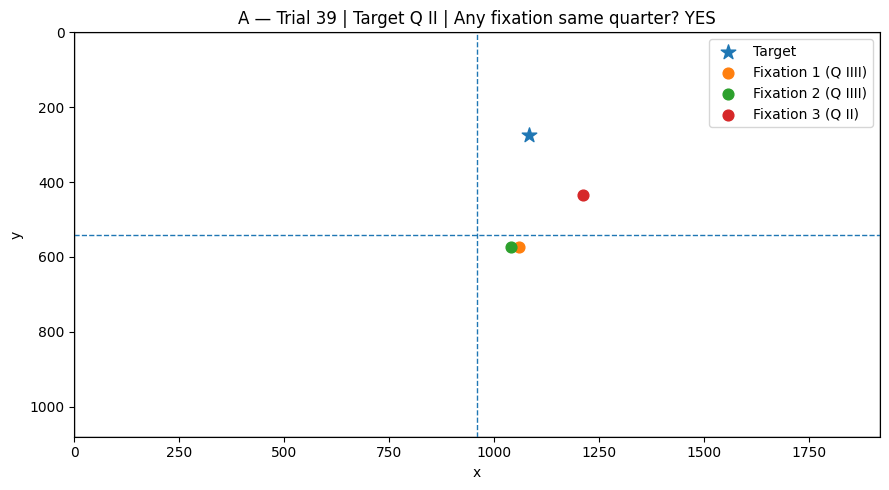

In [15]:
import matplotlib.pyplot as plt

def plot_single_trial_screen(final_dict, exp_key, trial_id, trial_col='N_trial',
                             x_target_col='txpos', y_target_col='typos',
                             fix_x_cols=('avrxpos_1','avrxpos_2','avrxpos_3'),
                             fix_y_cols=('avrypos_1','avrypos_2','avrypos_3')):
    df = final_dict[exp_key]
    row = df.loc[df[trial_col] == trial_id]
    if row.empty:
        raise ValueError(f"trial_id {trial_id} not found in experiment {exp_key}")
    r = row.iloc[0]

    tx, ty = float(r[x_target_col]), float(r[y_target_col])
    tq = get_quarter(tx, ty)

    fixes = []
    for fx_col, fy_col in zip(fix_x_cols, fix_y_cols):
        fx, fy = float(r[fx_col]), float(r[fy_col])
        fixes.append((fx, fy, get_quarter(fx, fy)))

    match_any = any(fq == tq for (_,_,fq) in fixes) #

    W, H = 1920, 1080
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.add_patch(plt.Rectangle((0, 0), W, H, fill=False, linewidth=1))

    ax.axvline(W/2, linestyle='--', linewidth=1)
    ax.axhline(H/2, linestyle='--', linewidth=1)

    ax.scatter([tx], [ty], s=120, marker='*', label='Target')

    for i, (fx, fy, fq) in enumerate(fixes, start=1):
        ax.scatter([fx], [fy], s=60, label=f'Fixation {i} (Q {fq})')

    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)  
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{exp_key} — Trial {trial_id} | Target Q {tq} | '
                 f'Any fixation same quarter? {"YES" if match_any else "NO"}')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_single_trial_screen(final_dict, exp_key='A', trial_id=39)


#import matplotlib.image as mpimg
#folders_image_dict = {}
#data_folder_name
#img = mpimg.imread('/Users/popadia1/Library/CloudStorage/OneDrive-AaltoUniversity/Desktop/Project/Eye_Tracking/to_share_to_learn/for_github/resp_0/Data/traces_shifted/alya12_atrack/traces_trial_39.png')

# Display the image
#plt.imshow(img)
#plt.axis('off')  # hides the axes
#plt.show()




In [16]:
#FOR OVERALL RESULTS AND STATS (it went from 39% to 55%)

def summarize_fixation_quadrants(final_dict,
                                 trial_col='N_trial',
                                 x_target_col='txpos', y_target_col='typos',
                                 fix_x_cols=('avrxpos_1', 'avrxpos_2', 'avrxpos_3'),
                                 fix_y_cols=('avrypos_1', 'avrypos_2', 'avrypos_3')):

    results = []

    for exp_key, df in final_dict.items():
        total_trials = len(df)
        same_quarter_count = 0

        for _, r in df.iterrows():
            tx, ty = float(r[x_target_col]), float(r[y_target_col])
            target_q = get_quarter(tx, ty)

            fix_quarters = []
            for fx_col, fy_col in zip(fix_x_cols, fix_y_cols):
                fx, fy = float(r[fx_col]), float(r[fy_col])
                fix_quarters.append(get_quarter(fx, fy))

            if any(fq == target_q for fq in fix_quarters):
                same_quarter_count += 1

        results.append({
            'Experiment': exp_key,
            'SameQuarter': same_quarter_count,
            'Total': total_trials,
            'Percent': 100 * same_quarter_count / total_trials if total_trials > 0 else 0
        })

    total_same = sum(r['SameQuarter'] for r in results)
    total_trials = sum(r['Total'] for r in results)

    for r in results:
        print(f"{r['Experiment']}: {r['SameQuarter']}/{r['Total']} "
              f"({r['Percent']:.1f}%) fixations in the same quarter as the target")

    print(f"\nOverall: {total_same}/{total_trials} "
          f"({100 * total_same / total_trials:.1f}%)")

    return results

results = summarize_fixation_quadrants(final_dict)


A: 27/50 (54.0%) fixations in the same quarter as the target
B: 29/49 (59.2%) fixations in the same quarter as the target
C: 28/49 (57.1%) fixations in the same quarter as the target
D: 26/50 (52.0%) fixations in the same quarter as the target

Overall: 110/198 (55.6%)


# NEWEST WORK. I plotted ALL fixations in a trial including target, and below it I create new new column that includes
# all fixations in SAME quadrlet as TAGRGET per trial and experiment. I compared the results can be compared to this new plot 
# and it seems to be accurate!

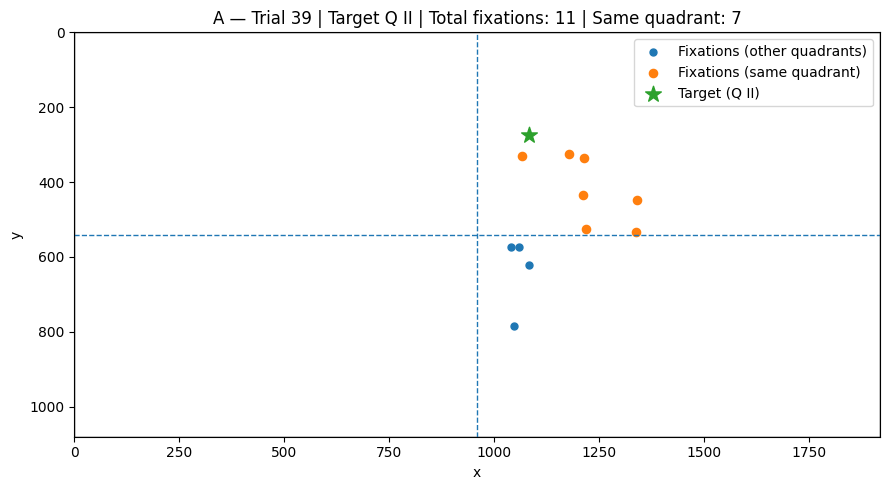

In [17]:
# PLOTTING ALL FIXATIONS IN TRIAL 
import matplotlib.pyplot as plt
import pandas as pd

def plot_trial_all_fixations(
    exp_key,
    trial_id,
    target_coords,         
    fixations_pd_in_dict,   
    W=1920, H=1080):
    tdf = target_coords[exp_key].copy()
    trow = tdf.loc[tdf["N_trial"] == trial_id]
    if trow.empty:
        raise ValueError(f"Trial {trial_id} not found in target_coords[{exp_key}]")
    tx = float(trow.iloc[0]["txpos"])
    ty = float(trow.iloc[0]["typos"])
    tq = get_quarter(tx, ty)

    #all fixations for this trial 
    fdf = fixations_pd_in_dict[exp_key].copy()
    fdf["trial_id"] = pd.to_numeric(fdf["trial_id"], errors="coerce").astype("Int64")
    ftrial = fdf.loc[fdf["trial_id"] == trial_id, ["avrxpos", "avrypos"]].dropna()
    if ftrial.empty:
        print(f"No fixations found for trial {trial_id} in experiment {exp_key}")
        fxs, fys = [], []
    else:
        fxs = ftrial["avrxpos"].astype(float).to_list()
        fys = ftrial["avrypos"].astype(float).to_list()

    fqs = [get_quarter(x, y) for x, y in zip(fxs, fys)]
    match_mask = [fq == tq for fq in fqs]

#PLOT    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.add_patch(plt.Rectangle((0, 0), W, H, fill=False, linewidth=1))
    ax.axvline(W/2, linestyle="--", linewidth=1)
    ax.axhline(H/2, linestyle="--", linewidth=1)
    if fxs:
        ax.scatter(
            [x for x, m in zip(fxs, match_mask) if not m],
            [y for y, m in zip(fys, match_mask) if not m],
            s=25,
            label="Fixations (other quadrants)"
        )
        ax.scatter(
            [x for x, m in zip(fxs, match_mask) if m],
            [y for y, m in zip(fys, match_mask) if m],
            s=35,
            label="Fixations (same quadrant)"
        )
    ax.scatter([tx], [ty], s=140, marker="*", label=f"Target (Q {tq})")
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)  
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(
        f"{exp_key} — Trial {trial_id} | Target Q {tq} | "
        f"Total fixations: {len(fxs)} | Same quadrant: {sum(match_mask)}"
    )
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


plot_trial_all_fixations(exp_key="A", trial_id=39, target_coords=target_coords, fixations_pd_in_dict=fixations_pd_in_dict)

In [18]:
# CREATING NEW COLUMN WITH FIXATIONS THAT ARE IN THE SAME QUADRLET AS TARGET. THESE WILL BE CALLED TARGET_FIXATIONS. 

#adds a column
for key, df in target_coords.items():
    df = df.copy()
    df["target_quarter"] = [get_quarter(x, y) for x, y in zip(df["txpos"], df["typos"])]
    target_coords[key] = df


#merging all fixations to corresponding quadrlet
same_quad_fixations = {}

for key, fix_df in fixations_pd_in_dict.items():
    f = fix_df.copy()
    f["trial_id"] = pd.to_numeric(f["trial_id"], errors="coerce").astype("Int64")
    t = target_coords[key][["N_trial", "target_quarter"]]  
    merged = f.merge(t, left_on="trial_id", right_on="N_trial", how="inner")
    merged["fix_quarter"] = [
        get_quarter(x, y) for x, y in zip(merged["avrxpos"], merged["avrypos"])
    ]
    matched = merged.loc[merged["fix_quarter"] == merged["target_quarter"]].copy()
    same_quad_fixations[key] = matched

#new dataframe that has trial, and all the fixations in target quadrlet of that specific trial
same_quad_summary = {}
for key, matched in same_quad_fixations.items():
    per_trial = (matched
        .groupby("trial_id")[["avrxpos", "avrypos"]]
        .apply(lambda d: list(map(tuple, d.to_numpy())))
        .reset_index(name="fixations_same_quadrant")
    )
    same_quad_summary[key] = per_trial

#mapping to final_dict (merge wouldn't work)
for key in final_dict.keys():
    m = same_quad_summary[key].set_index("trial_id")["fixations_same_quadrant"]
    final_dict[key]["fixations_same_quadrant"] = final_dict[key]["N_trial"].map(m).apply(
        lambda v: v if isinstance(v, list) else []
    )

#same_quad_summary['A']
#final_dict

# testing purposes, this shows how many fixations there are in target quadrlet per trial and experiment.
final_dict["A"]["n_fix_same_quadrant"] = (
    final_dict["A"]["fixations_same_quadrant"].apply(len))
final_dict["A"][["N_trial", "n_fix_same_quadrant"]]

,N_trial,n_fix_same_quadrant
0,3,0
1,4,2
2,5,2
3,6,0
4,7,2
5,8,2
6,9,2
7,10,2
8,12,2
9,13,4


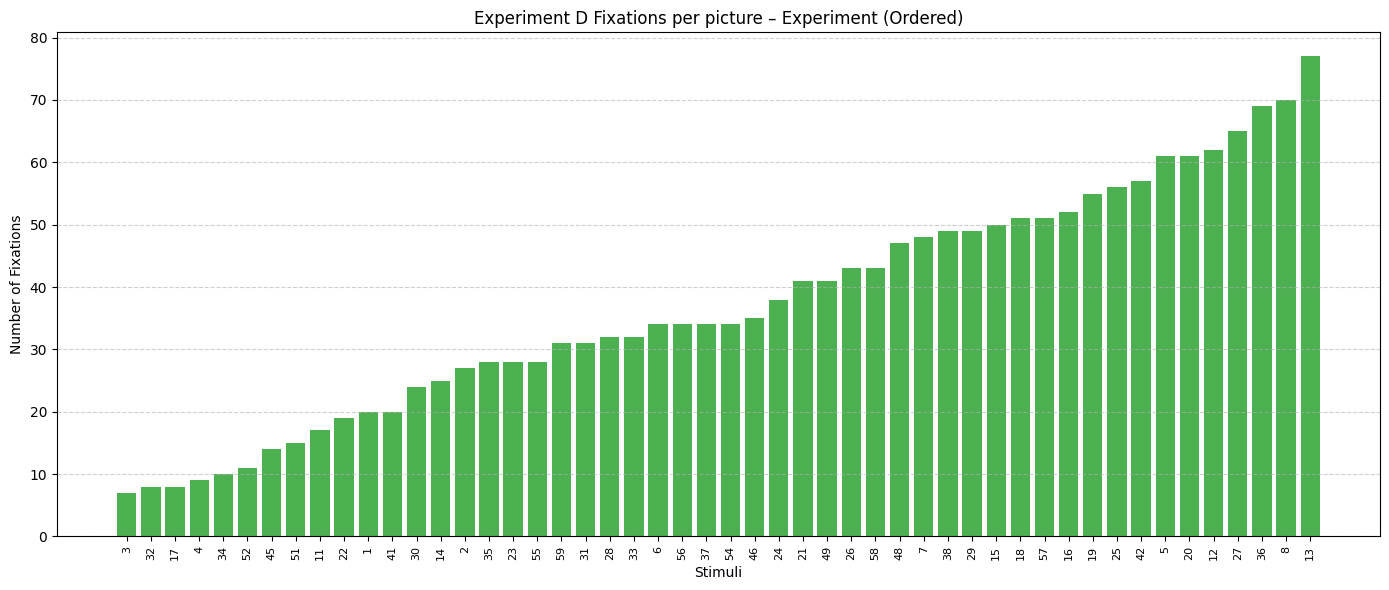

In [17]:


import numpy as np
import matplotlib.pyplot as plt

df_a = trials_data_dict['D'].copy()
df_a_sorted = df_a.sort_values('num_fix')

df_a_sorted = df_a_sorted[df_a_sorted['target_presence'] == True]


colors = '#4CAF50'

plt.figure(figsize=(14, 6))
plt.bar(df_a_sorted['trial_id'].astype(str), df_a_sorted['num_fix'], color=colors)

plt.title('Experiment D Fixations per picture – Experiment (Ordered)')
plt.xlabel('Stimuli')
plt.ylabel('Number of Fixations')
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Box Plot

# Third assignment


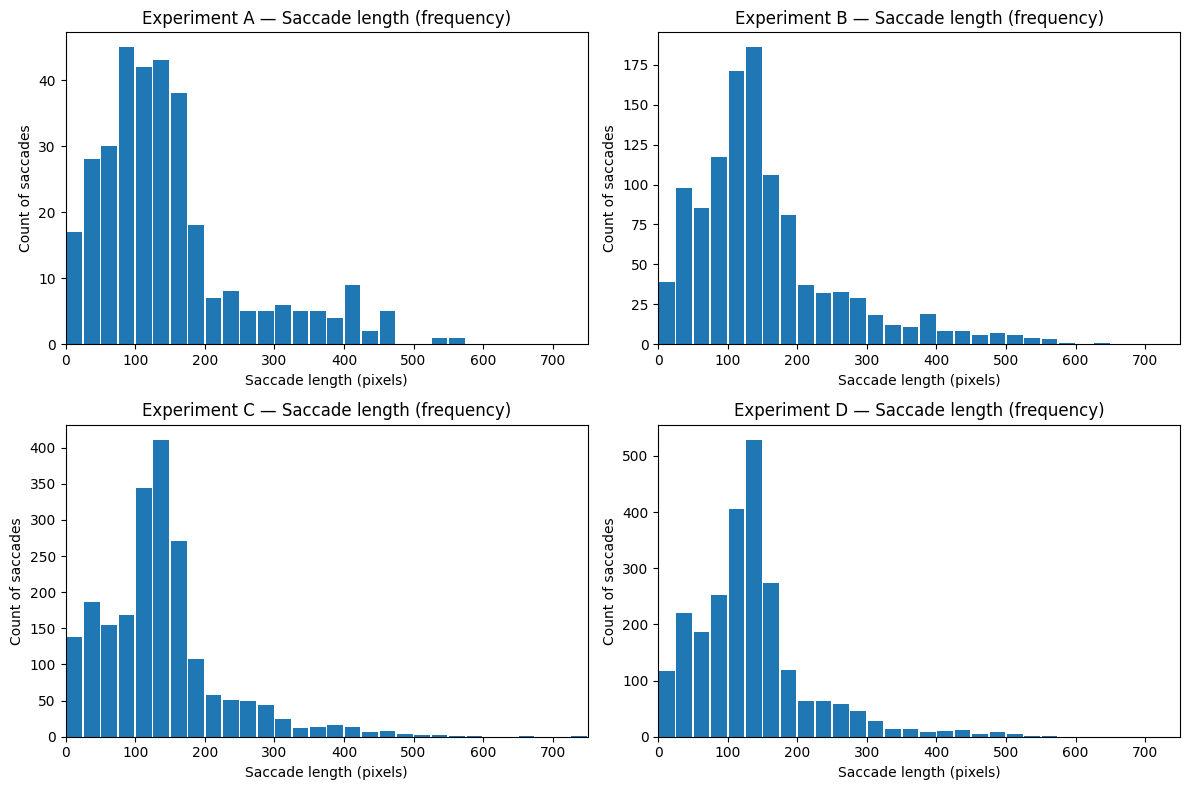

In [18]:

def plot_saccade_length_frequency(saccades_dict, experiments=('A','B','C','D'), bin_width=25):
    all_vals = []
    for k in experiments:
        vals = saccades_dict[k]['distance'].dropna().to_numpy()
        if vals.size: all_vals.append(vals)
    all_vals = np.concatenate(all_vals)
    gmin = np.floor(all_vals.min()/bin_width)*bin_width
    gmax = np.ceil(all_vals.max()/bin_width)*bin_width
    bins = np.arange(gmin, gmax + bin_width, bin_width)
    centers = (bins[:-1] + bins[1:]) / 2
    width = bin_width*0.9

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for ax, k in zip(axes, experiments):
        d = saccades_dict[k]['distance'].dropna().to_numpy()
        counts, _ = np.histogram(d, bins=bins)
        ax.bar(centers, counts, width=width, align='center')
        ax.set_title(f'Experiment {k} — Saccade length (frequency)')
        ax.set_xlabel('Saccade length (pixels)')
        ax.set_ylabel('Count of saccades')
        ax.set_xlim(bins[0], bins[-1])

    for ax in axes[len(experiments):]:
        ax.axis('off')

    plt.tight_layout(); plt.show()

plot_saccade_length_frequency(saccades_dict)



# Path Analysis

In [ ]:
# let's work with that data frame
fixations_pd_in_dict['A']

# grouping 

,trial_id,path_name_trial,eye,stime,etime,duration,avrxpos,avrypos,avrpupilsize,trial_id_num,target_presence,shifted_avrxpos,shifted_avrypos
0,49,C:\Users_Folder\Alina\VisualSearch_updated\Sti...,R,4818601,4818857,257,999.0,572.2,1686.0,49,False,901.0,536.2
1,49,C:\Users_Folder\Alina\VisualSearch_updated\Sti...,R,4818882,4819025,144,931.7,607.8,1581.0,49,False,833.7,571.8
2,49,C:\Users_Folder\Alina\VisualSearch_updated\Sti...,R,4819060,4819157,98,914.5,711.7,1189.0,49,False,816.5,675.7
3,49,C:\Users_Folder\Alina\VisualSearch_updated\Sti...,R,4819195,4819380,186,1297.7,775.9,940.0,49,False,1199.7,739.9
4,49,C:\Users_Folder\Alina\VisualSearch_updated\Sti...,R,4819406,4819659,254,1184.5,685.5,875.0,49,False,1086.5,649.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,41,C:\Users_Folder\Alina\VisualSearch_updated\Sti...,R,5133445,5133820,376,959.7,818.9,517.0,41,True,861.7,782.9
380,48,C:\Users_Folder\Alina\VisualSearch_updated\Sti...,R,5137943,5138163,221,1033.2,590.0,895.0,48,True,935.2,554.0
381,48,C:\Users_Folder\Alina\VisualSearch_updated\Sti...,R,5138181,5138306,126,1066.6,572.6,901.0,48,True,968.6,536.6
382,48,C:\Users_Folder\Alina\VisualSearch_updated\Sti...,R,5138327,5138437,111,990.1,528.3,736.0,48,True,892.1,492.3
